In [3]:
import os
import pathlib
import matplotlib.pyplot as plt
import json

node_logs = []

logs_dir = pathlib.Path(f"./results_centralised").resolve()
if logs_dir.exists():
    logs = logs_dir.glob("*.txt")
    latest_log = None
    for log in logs:
        if latest_log == None:
            latest_log = log
            continue
        current_timestamp = log.name.replace("log_","").replace(".txt","")
        lastest_timestamp = latest_log.name.replace("log_","").replace(".txt","")
        if float(current_timestamp)>float(lastest_timestamp):
            latest_log = log
    if latest_log:
        node_logs = json.loads(latest_log.read_text())

print(node_logs)


[[[0.4408076157172521, 0.24167874364591227, 0.2059992332526339, 0.19097129461484227, 0.18276578533213314, 0.17762076915279637, 0.1742064774157555, 0.17130832646678135, 0.1691807070519866, 0.16675071563662552, 0.16462078163536584, 0.1623829858816736, 0.16041495178530857, 0.15799327606592722, 0.15567712140519444, 0.1530130928367134, 0.1504046442062874, 0.14763346841422523, 0.14491012598562047, 0.14225695875844335, 0.13968137454816965, 0.13687354344420316, 0.13424129823480196, 0.13127418265231255, 0.12865054610420049, 0.1260950006241721, 0.12337407487921598, 0.12050734726878685, 0.1176815300089557, 0.11512475288132341, 0.1127126613646988, 0.10991582495531416, 0.1072167705714218, 0.1047097976372494, 0.10215587720153778, 0.09988370895143447, 0.09698451822245024, 0.09449523402665688, 0.09209505192996041, 0.08977301115912151, 0.08747935967474449, 0.08538273007162218, 0.0832018305252238, 0.08037565924166663, 0.0783009647989903, 0.07592856119258132, 0.07427047040101474, 0.07203095565300162, 0.0

In [4]:

import numpy as np


avg_train_loss = node_logs[0][0]
avg_train_acc = node_logs[0][1]
avg_val_loss = node_logs[1][0]
avg_val_acc = node_logs[1][1]

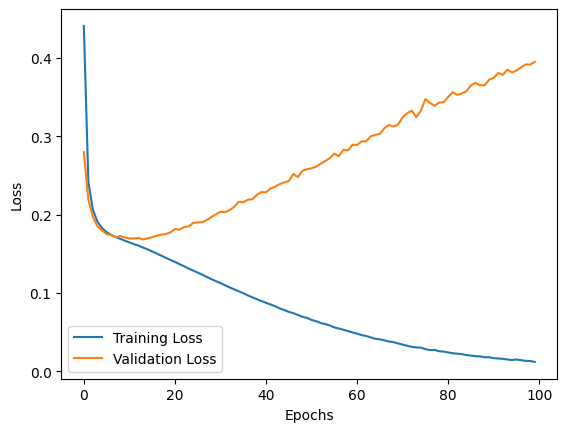

Epochs : 100


In [5]:
plt.plot(avg_train_loss,label="Training Loss")
plt.plot(avg_val_loss,label="Validation Loss")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()
print(f"Epochs : {len(avg_train_acc)}")

In [6]:
columns = ('Training Accuracy', 'Validation Accuracy')
rows = [1,5,10, 25, 50, 75, 100]

train_accs = [f"{round(avg_train_acc[rows[i]-1]*100,3)}%" for i in range(len(rows))]
val_accs = [f"{round(avg_val_acc[rows[i]-1]*100,3)}%" for i in range(len(rows))]
import pandas as pd

pd.DataFrame(np.transpose([train_accs,val_accs]),columns=columns,index=rows)

,Training Accuracy,Validation Accuracy
1,84.398%,94.883%
5,94.858%,94.915%
10,94.892%,94.879%
25,95.667%,94.259%
50,97.767%,93.362%
75,99.163%,92.996%
100,99.76%,92.88%


In [7]:
val_max = max(avg_val_acc)
print(f"Best Validation Accuracy : {round(val_max*100,3)}%")

Best Validation Accuracy : 94.924%
